In [1]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean.cm as cmo
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import dbof.global_dataset_creation.zarr_dataset_global as zarr_dataset
import dbof.global_dataset_creation.zarr_grid_global    as zarr_grid
import dbof.io.filesystems as filesystems

# ── Load config ─────────────────────────────────────────────────────────────────────────
path_to_config = "../../configs/global/access_surf.yaml"
with open(path_to_config) as f:
    cfg = yaml.safe_load(f)

data_cfg = cfg["data_access"]
grid_cfg = cfg["grid_access"]

bucket      = data_cfg["bucket"]
folder      = data_cfg["folder"]
run_id      = data_cfg["run_id"]
s3_endpoint = data_cfg["s3_endpoint"]

# ── Filesystem (created once, reused by both data and grid readers) ───────────
fs, fs_synch = filesystems.create_s3_filesystems(s3_endpoint)

# ── Discover timestamps and subsets ─────────────────────────────────────────────
run_root = f"{bucket}/{folder}/{run_id}"

ts_entries = fs_synch.ls(run_root, detail=True)
timestamps = sorted(e["name"].split("/")[-1] for e in ts_entries if e["type"] == "directory")
print(f"Timestamps found ({len(timestamps)}):")
for ts in timestamps:
    print(f"  {ts}")

subset_map = {}  # {timestamp: [dataset_name, ...]}
for ts in timestamps:
    entries = fs_synch.ls(f"{run_root}/{ts}", detail=True)
    subset_map[ts] = sorted(
        e["name"].split("/")[-1]
        for e in entries
        if e["type"] == "directory" and e["name"].endswith(".zarr")
    )
    print(f"\nSubsets under {ts}:")
    for s in subset_map[ts]:
        print(f"  {s}")

Timestamps found (2):
  20120209_120000
  20120801_120000

Subsets under 20120209_120000:
  frontal_structure.zarr
  icearea.zarr
  kinematic.zarr
  native_fields.zarr
  surface_wind.zarr

Subsets under 20120801_120000:
  frontal_structure.zarr
  icearea.zarr
  kinematic.zarr
  native_fields.zarr
  surface_wind.zarr


In [6]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
TIMESTAMP  = timestamps[1]              # e.g. "20121109_120000"
DATASET    = "surface_wind.zarr"  # e.g. "native_fields.zarr"
FIELD      = "oceTAUX"                       # None → first channel in the subset
TIMESTEP   = 0
DS_GLOBAL  = 20
# ════════════════════════════════════════════════════════════════════════════════

reader = zarr_dataset.GlobalZarrDatasetReader(
    bucket=bucket,
    folder=folder,
    run_id=run_id,
    dataset_name=DATASET,
    date_prefix=TIMESTAMP,
    fs=fs,
)
print(f"Loaded  : s3://{bucket}/{folder}/{run_id}/{TIMESTAMP}/{DATASET}")
print(f"Channels: {reader.channel_names}")
print(f"Shape   : {reader.shape}  (T, C, H, W)")
print(f"Iteration : {reader.iteration}")

if FIELD is None:
    FIELD = reader.channel_names[0]
print(f"\nField to plot: {FIELD}")

# ── Grid ─────────────────────────────────────────────────────────────────────────────
grid_reader = zarr_grid.GlobalGridZarrReader(
    bucket=grid_cfg["bucket"],
    folder=grid_cfg["folder"],
    dataset_name=grid_cfg["dataset_name"],
    fs=fs,
)
XC   = grid_reader.lon
YC   = grid_reader.lat
XC_g = XC[::DS_GLOBAL, ::DS_GLOBAL]
YC_g = YC[::DS_GLOBAL, ::DS_GLOBAL]

Loaded  : s3://dbof/test_data_for_cutouts/cutout_test_data_v1/20120801_120000/surface_wind.zarr
Channels: ['oceTAUX', 'oceTAUY']
Shape   : (2, 12960, 17280)  (T, C, H, W)
Iteration : 1128384

Field to plot: oceTAUX


In [11]:
print(TIMESTAMP)

20120801_120000


In [7]:
reader.channel_names

['oceTAUX', 'oceTAUY']

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


ValueError: vmin, vcenter, and vmax must be in ascending order

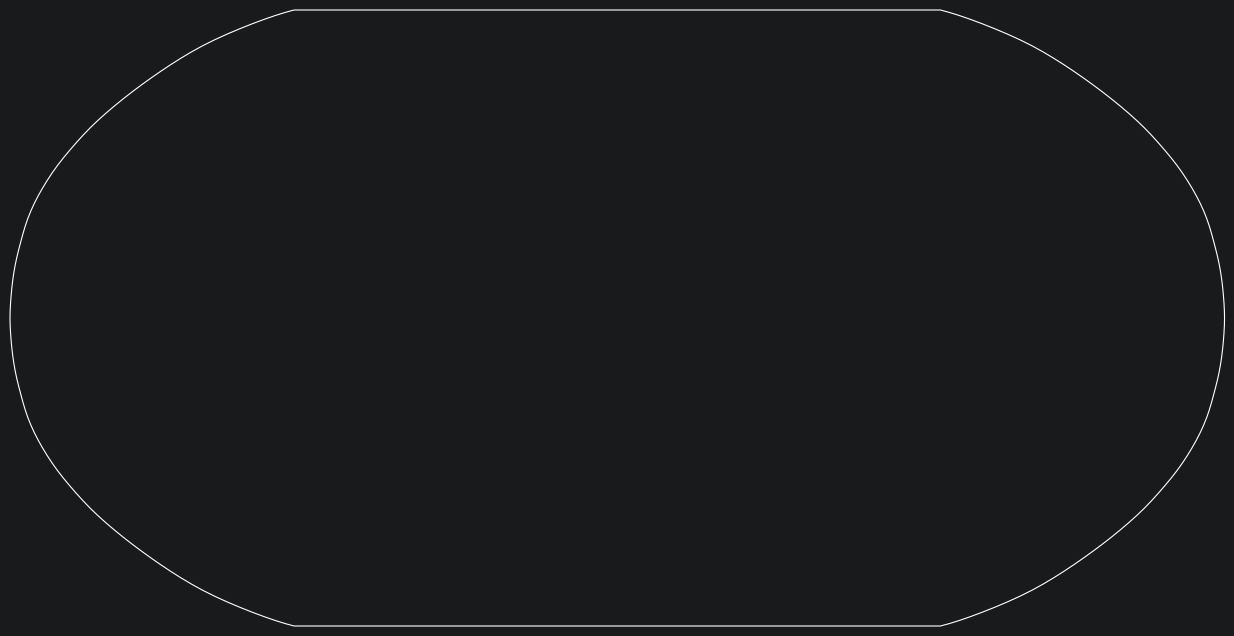

In [9]:
from dbof.plotting.field_cmaps import load_field_cmaps
from dbof.plotting.global_maps import plot_global_field

# Shared per-channel colormap + label registry (src/dbof/plotting/field_cmaps.yaml).
CMAP_CFG, DIVERGING_CMAPS = load_field_cmaps()

arr = reader.get_channel_snapshot(FIELD)[::DS_GLOBAL, ::DS_GLOBAL]

print(arr)

fig = plt.figure(figsize=(16, 8))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
im, label = plot_global_field(
    ax, XC_g, YC_g, arr, FIELD, CMAP_CFG,
    diverging_cmaps=DIVERGING_CMAPS,
    transform=ccrs.PlateCarree(),
)
ax.gridlines(linewidth=0.4, color='gray', alpha=0.6)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, shrink=0.7,
             label=label, orientation='horizontal')
ax.set_title(f'LLC4320 {FIELD}  |  {DS_GLOBAL}× downsampled', fontsize=13)
plt.suptitle(
    f'{run_id} / {TIMESTAMP} / {DATASET}  —  iteration {reader.iteration}',
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()